# **CSC2042S: Assignment 2**

# **Multinomial Logistic Regression for News Topic Classification**

**Name:** Sanele Hopewell Nkosi  
**Student Number:** nkssan033

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import random
import string
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Set random seeds
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## **Question1:DATA PROCESSING**
The MasakhaNEWS training, development, and test datasets are loaded for English, isiXhosa, and chiShona. The headline and article text are combined, cleaned, and tokenised. The class labels are also converted into numerical values for use by the classification model.

In [3]:
import csv
def read_Masakha_News(file_path):
    """
    Read a MasakhaNEWS TSV file and return its articles as dictionaries.

    Returns:
        A list of dictionaries containing the article fields and values.
    """
    with open(file_path, encoding="utf-8") as file:
        data = list(
            csv.DictReader(
                file,
                delimiter="\t"
            )
        )

    return data

In [4]:
# English datasets
eng_train = read_Masakha_News("eng/train.tsv")
eng_dev = read_Masakha_News("eng/dev.tsv")
eng_test = read_Masakha_News("eng/test.tsv")

# isiXhosa datasets
xho_train = read_Masakha_News("xho/train.tsv")
xho_dev = read_Masakha_News("xho/dev.tsv")
xho_test = read_Masakha_News("xho/test.tsv")

# chiShona datasets
sna_train = read_Masakha_News("sna/train.tsv")
sna_dev = read_Masakha_News("sna/dev.tsv")
sna_test = read_Masakha_News("sna/test.tsv")

In [5]:
print("English")
print("Training:",len(eng_train))
print("Development:",len(eng_dev))
print("Test:",len(eng_test))

print("\nisiXhosa")
print("Training:",len(xho_train))
print("Development:",len(xho_dev))
print("Test:",len(xho_test))

print("\nchiShona")
print("Training:",len(sna_train))
print("Development:",len(sna_dev))
print("Test:",len(sna_test))

English
Training: 3309
Development: 472
Test: 948

isiXhosa
Training: 1032
Development: 147
Test: 297

chiShona
Training: 1288
Development: 185
Test: 369


In [6]:
print(eng_train[0].keys())

dict_keys(['category', 'headline', 'text', 'url'])


In [7]:
def clean_text(text):
    """
    Apply basic cleaning to a text string.
    Returns: The lowercase text with punctuation and extra whitespace removed.
    """
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    
    return text

In [8]:
def prepare_data(data):
    """
    Combine and clean the headline and article text.

    Returns:
        A list of cleaned article texts and a list of category labels.
    """
    texts = []
    categories = []

    for article in data:
        combined_text = article["headline"] + " " + article["text"]
        combined_text = clean_text(combined_text)

        texts.append(combined_text)
        categories.append(article["category"])

    return texts, categories

In [9]:
# English
eng_train_texts, eng_train_categories = prepare_data(eng_train)
eng_dev_texts, eng_dev_categories = prepare_data(eng_dev)
eng_test_texts, eng_test_categories = prepare_data(eng_test)

# isiXhosa
xho_train_texts, xho_train_categories = prepare_data(xho_train)
xho_dev_texts, xho_dev_categories = prepare_data(xho_dev)
xho_test_texts, xho_test_categories = prepare_data(xho_test)

# chiShona
sna_train_texts, sna_train_categories = prepare_data(sna_train)
sna_dev_texts, sna_dev_categories = prepare_data(sna_dev)
sna_test_texts, sna_test_categories = prepare_data(sna_test)

In [10]:
def tokenise_text(text):
    """Split cleaned text into individual tokens.
    Returns:A list containing the tokens in the text.
    """
    return text.split()

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## **QUESTION 2:MULTINOMINAL LOGISTIC REGRESSION IMPLEMENTATION**

In [12]:
class MultinomialLogisticRegression(nn.Module):
    """
    Implement multinomial logistic regression using a linear layer.
    """
    def __init__(self, num_features, num_classes):
        """
        Initialise the multinomial logistic regression model.
        num_features: Number of input features.
        num_classes: Number of output categories.
        """
        super(MultinomialLogisticRegression, self).__init__()
        
        self.linear = nn.Linear(num_features, num_classes)
    
    
    def forward(self, x):
        """
        Calculate the raw class scores for a batch of observations.
        Returns:The logits produced for every class.
        """
        logits = self.linear(x)
        
        return logits
    
    
    def compute_probabilities(self, x):
        """
        Convert the model logits into class probabilities.

        Returns:The softmax probability of each class for every observation.
        """
        logits = self.forward(x)
        probabilities = torch.softmax(logits, dim=1)
        
        return probabilities
    
    
    def predict(self, x):
        """
        Predict the category of every observation in a batch.
        Returns:The numerical index of the most probable class for each observation.
        """
        probabilities = self.compute_probabilities(x)
        predictions = torch.argmax(probabilities, dim=1)
        
        return predictions

## **QUESTION 3:TRAINING**

In [13]:

def create_category_mapping(categories):
    """
    Create a mapping from category names to numerical class labels.

    Returns:A dictionary mapping each category to a numerical label.
    """
    unique_categories = sorted(set(categories))
    category_to_number = {}

    # Assign a numerical value to each unique category
    for number, category in enumerate(unique_categories):
        category_to_number[category] = number

    # Return the completed mapping
    return category_to_number

In [14]:
# Creating the English category mapping using the training categories
eng_category_to_number = create_category_mapping(
    eng_train_categories
)

# Create the isiXhosa category mapping using the training categories
xho_category_to_number = create_category_mapping(
    xho_train_categories
)

# Create the chiShona category mapping using the training categories
sna_category_to_number = create_category_mapping(
    sna_train_categories
)

In [15]:
# Display the category mappings for each language
print("English:", eng_category_to_number)
print("isiXhosa:", xho_category_to_number)
print("chiShona:", sna_category_to_number)

English: {'business': 0, 'entertainment': 1, 'health': 2, 'politics': 3, 'sports': 4, 'technology': 5}
isiXhosa: {'business': 0, 'entertainment': 1, 'health': 2, 'politics': 3, 'sports': 4}
chiShona: {'business': 0, 'health': 1, 'politics': 2, 'sports': 3}


In [16]:
# Converts category names into numerical class labels
def encode_categories(categories, category_to_number):
    """
    Convert category names into numerical PyTorch labels.

    Returns:
        A PyTorch tensor containing the encoded class labels.
    """
    
    # Creates an empty list for the numerical labels
    encoded_categories = []

    # Convert each category name into its corresponding number
    for category in categories:
        encoded_categories.append(category_to_number[category])

    # Convert the list of labels into a PyTorch tensor
    return torch.tensor(encoded_categories)

In [17]:
# Encode the English training categories
eng_train_labels = encode_categories(
    eng_train_categories,
    eng_category_to_number
)

# Encode the English development categories
eng_dev_labels = encode_categories(
    eng_dev_categories,
    eng_category_to_number
)

# Encode the English test categories
eng_test_labels = encode_categories(
    eng_test_categories,
    eng_category_to_number
)

In [18]:
# Encode the isiXhosa training categories
xho_train_labels = encode_categories(
    xho_train_categories,
    xho_category_to_number
)

# Encode the isiXhosa development categories
xho_dev_labels = encode_categories(
    xho_dev_categories,
    xho_category_to_number
)

# Encode the isiXhosa test categories
xho_test_labels = encode_categories(
    xho_test_categories,
    xho_category_to_number
)

In [19]:
# Encode the chiShona training categories
sna_train_labels = encode_categories(
    sna_train_categories,
    sna_category_to_number
)

# Encode the chiShona development categories
sna_dev_labels = encode_categories(
    sna_dev_categories,
    sna_category_to_number
)

# Encode the chiShona test categories
sna_test_labels = encode_categories(
    sna_test_categories,
    sna_category_to_number
)

In [20]:
# Create mini-batches from the sparse text-feature matrix
def create_batches(features, labels, batch_size, shuffle):
    """
    Create mini-batches from a sparse feature matrix and label tensor.
    Yields:A dense feature tensor and its corresponding label tensor.
    """
    
    # Find the total number of observations
    number_of_examples = features.shape[0]

    # Shuffle the observation indices for training
    if shuffle:
        indices = torch.randperm(number_of_examples)
    
    # Keep the original order during validation
    else:
        indices = torch.arange(number_of_examples)

    # Move through the observations one mini-batch at a time
    for start in range(0, number_of_examples, batch_size):
        
        # Determine where the current batch ends
        end = start + batch_size

        # Select the indices for the current batch
        batch_indices = indices[start:end]

        # Convert the indices to NumPy for indexing the sparse matrix
        numpy_indices = batch_indices.numpy()

        # Select the feature rows for the current batch
        # and convert them into a dense PyTorch tensor
        batch_features = torch.tensor(
            features[numpy_indices].toarray(),
            dtype=torch.float32
        )

        # Select the labels corresponding to the current batch
        batch_labels = labels[batch_indices]

        # Return the current batch to the training or validation loop
        yield batch_features, batch_labels

## ***QUESTION 4:FEATURE EXTRACTION***


## **ENGLISH FEATURE EXTRACTION**

In [21]:
# Bag-of-Words count features for English
eng_count_vectorizer = CountVectorizer(binary=False)

eng_train_bow = eng_count_vectorizer.fit_transform(eng_train_texts)
eng_dev_bow = eng_count_vectorizer.transform(eng_dev_texts)
eng_test_bow = eng_count_vectorizer.transform(eng_test_texts)


# Binary presence or absence features for English
eng_binary_vectorizer = CountVectorizer(binary=True)

eng_train_binary = eng_binary_vectorizer.fit_transform(eng_train_texts)
eng_dev_binary = eng_binary_vectorizer.transform(eng_dev_texts)
eng_test_binary = eng_binary_vectorizer.transform(eng_test_texts)


# TF-IDF features for English
eng_tfidf_vectorizer = TfidfVectorizer()

eng_train_tfidf = eng_tfidf_vectorizer.fit_transform(eng_train_texts)
eng_dev_tfidf = eng_tfidf_vectorizer.transform(eng_dev_texts)
eng_test_tfidf = eng_tfidf_vectorizer.transform(eng_test_texts)

## **ISIXHOSA FEATURE EXTRACTION**

In [22]:
# Bag-of-Words count features for isiXhosa
xho_count_vectorizer = CountVectorizer(binary=False)

xho_train_bow = xho_count_vectorizer.fit_transform(xho_train_texts)
xho_dev_bow = xho_count_vectorizer.transform(xho_dev_texts)
xho_test_bow = xho_count_vectorizer.transform(xho_test_texts)


# Binary presence or absence features for isiXhosa
xho_binary_vectorizer = CountVectorizer(binary=True)

xho_train_binary = xho_binary_vectorizer.fit_transform(xho_train_texts)
xho_dev_binary = xho_binary_vectorizer.transform(xho_dev_texts)
xho_test_binary = xho_binary_vectorizer.transform(xho_test_texts)


# TF-IDF features for isiXhosa
xho_tfidf_vectorizer = TfidfVectorizer()

xho_train_tfidf = xho_tfidf_vectorizer.fit_transform(xho_train_texts)
xho_dev_tfidf = xho_tfidf_vectorizer.transform(xho_dev_texts)
xho_test_tfidf = xho_tfidf_vectorizer.transform(xho_test_texts)

## **CHISHONA FEATURE EXTRACTION**

In [23]:
# Bag-of-Words count features for chiShona
sna_count_vectorizer = CountVectorizer(binary=False)

sna_train_bow = sna_count_vectorizer.fit_transform(sna_train_texts)
sna_dev_bow = sna_count_vectorizer.transform(sna_dev_texts)
sna_test_bow = sna_count_vectorizer.transform(sna_test_texts)


# Binary presence or absence features for chiShona
sna_binary_vectorizer = CountVectorizer(binary=True)

sna_train_binary = sna_binary_vectorizer.fit_transform(sna_train_texts)
sna_dev_binary = sna_binary_vectorizer.transform(sna_dev_texts)
sna_test_binary = sna_binary_vectorizer.transform(sna_test_texts)


# TF-IDF features for chiShona
sna_tfidf_vectorizer = TfidfVectorizer()

sna_train_tfidf = sna_tfidf_vectorizer.fit_transform(sna_train_texts)
sna_dev_tfidf = sna_tfidf_vectorizer.transform(sna_dev_texts)
sna_test_tfidf = sna_tfidf_vectorizer.transform(sna_test_texts)

# Question 5: Hyperparameter Tuning

In [24]:

feature_methods = [
    "Bag-of-Words",
    "Binary",
    "TF-IDF"]

# Learning rates considered for stochastic gradient descent
learning_rates = [
    0.1,
    0.5,
    1.0]

# Mini-batch sizes considered during training
batch_sizes = [
    64,
    128,
    256]

# Maximum numbers of vocabulary features
maximum_vocabulary_sizes = [
    5000,
    10000,
    20000]

# Minimum term frequencies specified
minimum_frequencies = [
    0,
    3,
    5,
    10]

# Maximum number of training epochs
maximum_epochs = 50

# Stop if development loss does not improve for this many epochs
patience = 5

In [25]:
# Create numerical features for one tuning configuration
def create_tuning_features(
    train_texts,
    dev_texts,
    feature_method,
    max_features,
    min_df):
    """
    Create training and development features for one configuration.

    Returns:The fitted vectoriser, training features, and development features.
    """
    if min_df == 0:
        vectorizer_min_df = 1
    else:
        vectorizer_min_df = min_df

    # Create Bag-of-Words count features
    if feature_method == "Bag-of-Words":

        vectorizer = CountVectorizer(
            binary=False,
            max_features=max_features,
            min_df=vectorizer_min_df
        )

    # Create binary presence-or-absence features
    elif feature_method == "Binary":

        vectorizer = CountVectorizer(
            binary=True,
            max_features=max_features,
            min_df=vectorizer_min_df
        )

    # Create TF-IDF features
    elif feature_method == "TF-IDF":

        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=vectorizer_min_df
        )

    # Stop if an unsupported method is supplied
    else:

        raise ValueError(
            "Unknown feature extraction method"
        )

    # Learn the vocabulary from the training data
    # and create the training vectors
    train_features = vectorizer.fit_transform(
        train_texts
    )

    # Transform the development data using
    # the vocabulary learned from training data
    dev_features = vectorizer.transform(
        dev_texts
    )

    # Return the fitted vectoriser and feature matrices
    return (
        vectorizer,
        train_features,
        dev_features
    )

In [26]:
# Calculate model accuracy on a numerical feature matrix
def calculate_accuracy(model, features, labels, batch_size):
    """
    Calculate classification accuracy for a model.

    Returns:The proportion of correctly classified observations.
    """

    # Put the model into evaluation mode
    model.eval()

    # Count the correct predictions
    correct = 0

    # Count the total number of observations
    total = 0

    # Create evaluation mini-batches without shuffling
    data_loader = create_batches(
        features,
        labels,
        batch_size,
        shuffle=False
    )

    # Disable gradient calculations during evaluation
    with torch.no_grad():

        # Evaluate one mini-batch at a time
        for batch_features, batch_labels in data_loader:

            # Calculate the raw class scores
            outputs = model(batch_features)

            # Select the class with the largest score
            _, predicted = torch.max(
                outputs.data,
                1
            )

            # Count all observations in the batch
            total += batch_labels.size(0)

            # Count the correct predictions
            correct += (
                predicted == batch_labels
            ).sum().item()

    # Calculate the accuracy
    accuracy = correct / total

    return accuracy

In [27]:
# Train one model and select the best epoch using development loss
def train_tuning_model(train_features,train_labels,dev_features,dev_labels,num_classes,learning_rate,batch_size,maximum_epochs,
    patience
):
    """
    Train and validate one hyperparameter configuration.
    Returns:
        The best model, loss histories, development accuracies,
        best development accuracy, best development loss, and best epoch.
    """

    # Reset the seeds so that configurations are comparable
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    # Determine the number of numerical input features
    input_size = train_features.shape[1]

    # Create a new multinomial logistic regression model
    model = MultinomialLogisticRegression(
        input_size,
        num_classes
    )

    # Create a new stochastic gradient descent optimiser
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    # Store the average loss from every epoch
    training_losses = []
    development_losses = []

    # Store the development accuracy from every epoch
    development_accuracies = []

    # Start with an infinitely large best development loss
    best_development_loss = float("inf")

    # Store the best development accuracy
    best_development_accuracy = 0.0

    # Store the best training epoch
    best_epoch = 0

    # Count epochs without development-loss improvement
    epochs_without_improvement = 0

    # Store the parameters of the best model
    best_model_state = None

    # Repeat training up to the maximum number of epochs
    for epoch in range(maximum_epochs):

      
        # Puts the model into training mode
        model.train()

        # Reset the accumulated training loss
        total_training_loss = 0.0

        # Reset the count of training observations
        total_training_examples = 0

        # Create shuffled training mini-batches
        train_loader = create_batches(
            train_features,
            train_labels,
            batch_size,
            shuffle=True
        )

        # Process one training mini-batch at a time
        for features, labels in train_loader:

            # Calculate the raw output logits
            outputs = model(features)

            # Ensure that the labels are integer class indices
            labels = labels.long()

            # Calculate multiclass cross-entropy loss
            loss = F.cross_entropy(
                outputs,
                labels
            )

            # Clear gradients from the previous mini-batch
            optimizer.zero_grad()

            # Calculate gradients for the current mini-batch
            loss.backward()

            # Update the model parameters
            optimizer.step()

            # Add the weighted batch loss to the total loss
            total_training_loss += (
                loss.item() * labels.size(0)
            )

            # Count the training observations
            total_training_examples += labels.size(0)

        # Calculate average training loss for the epoch
        average_training_loss = (
            total_training_loss /
            total_training_examples
        )

        
        # Put the model into evaluation mode
        model.eval()

        # Reset the accumulated development loss
        total_development_loss = 0.0

        # Reset the count of development observations
        total_development_examples = 0

        # Count correct development predictions
        correct_development_predictions = 0

        # Create development mini-batches without shuffling
        development_loader = create_batches(
            dev_features,
            dev_labels,
            batch_size,
            shuffle=False
        )

        # Disable gradient calculations during development evaluation
        with torch.no_grad():

            # Process one development mini-batch at a time
            for features, labels in development_loader:

                # Calculate the development logits
                outputs = model(features)

                # Ensure that labels are integer class indices
                labels = labels.long()

                # Calculate development cross-entropy loss
                loss = F.cross_entropy(
                    outputs,
                    labels
                )

                # Add the weighted batch loss
                total_development_loss += (
                    loss.item() * labels.size(0)
                )

                # Count the development observations
                total_development_examples += labels.size(0)

                # Select the predicted class
                _, predicted = torch.max(
                    outputs.data,
                    1
                )

                # Count the correct predictions
                correct_development_predictions += (
                    predicted == labels
                ).sum().item()

        # Calculate the average development loss
        average_development_loss = (
            total_development_loss /
            total_development_examples
        )

        # Calculate development accuracy
        development_accuracy = (
            correct_development_predictions /
            total_development_examples
        )

        # Store the training results for this epoch
        training_losses.append(
            average_training_loss
        )

        development_losses.append(
            average_development_loss
        )

        development_accuracies.append(
            development_accuracy
        )

       
        # Early stopping
       

        # Check whether development loss improved
        if average_development_loss < best_development_loss:

            # Store the new best development loss
            best_development_loss = (
                average_development_loss
            )

            # Store development accuracy from the best epoch
            best_development_accuracy = (
                development_accuracy
            )

            # Store the best epoch number
            best_epoch = epoch + 1

            # Reset the early-stopping counter
            epochs_without_improvement = 0

            # Save a separate copy of every model parameter
            best_model_state = {
                parameter_name:
                parameter_value.detach().clone()

                for parameter_name, parameter_value
                in model.state_dict().items()
            }

        else:

            # Count an epoch without improvement
            epochs_without_improvement += 1

        # Stop when development loss has not improved
        # for the selected number of consecutive epochs
        if epochs_without_improvement >= patience:
            break

    # Restore the model parameters from the best epoch
    model.load_state_dict(
        best_model_state
    )

    # Return the best model and the recorded training history
    return (
        model,
        training_losses,
        development_losses,
        development_accuracies,
        best_development_accuracy,
        best_development_loss,
        best_epoch
    )

In [28]:
# Run one language-feature-hyperparameter configuration
def run_tuning_configuration(train_texts,dev_texts,train_labels,dev_labels,num_classes,feature_method,learning_rate,batch_size,max_features,min_df,maximum_epochs,patience):
    """
    Run one complete feature extraction and training configuration.

    Returns:The configuration results, trained model, and fitted vectoriser.
    """

    # Create numerical training and development features
    (
        vectorizer,
        train_features,
        dev_features
    ) = create_tuning_features(
        train_texts,
        dev_texts,
        feature_method,
        max_features,
        min_df
    )

    # Train a new model for the current configuration
    (
        model,
        training_losses,
        development_losses,
        development_accuracies,
        best_development_accuracy,
        best_development_loss,
        best_epoch
    ) = train_tuning_model(
        train_features,
        train_labels,
        dev_features,
        dev_labels,
        num_classes,
        learning_rate,
        batch_size,
        maximum_epochs,
        patience
    )

    # Store all important details for this configuration
    result = {
        "feature_method": feature_method,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "max_features": max_features,
        "min_df": min_df,
        "actual_vocabulary_size": train_features.shape[1],
        "best_epoch": best_epoch,
        "best_development_loss": best_development_loss,
        "best_development_accuracy": best_development_accuracy,
        "training_losses": training_losses,
        "development_losses": development_losses,
        "development_accuracies": development_accuracies
    }

    # Return the results and fitted objects
    return (
        result,
        model,
        vectorizer
    )

In [29]:
# Tune all required hyperparameters for one feature method
def tune_language_feature_combination(language_name,train_texts,dev_texts,train_labels,dev_labels,num_classes,feature_method,maximum_epochs,patience):
    """
    Tune all required hyperparameters for one language-feature combination.
    Returns:All configuration results and the selected model, vectoriser,and hyperparameters.
    """

    # Store every configuration tested
    configuration_results = []

    # Store the best result found so far
    best_result = None

    # Store the best trained model
    best_model = None

    # Store the vectoriser belonging to the best model
    best_vectorizer = None

    print("\nLanguage:", language_name)
    print("Feature method:", feature_method)

    # Compare every learning rate
    for learning_rate in learning_rates:

        # Compare every batch size
        for batch_size in batch_sizes:

            # Compare every maximum vocabulary size
            for max_features in maximum_vocabulary_sizes:

                # Compare every minimum term frequency
                for min_df in minimum_frequencies:

                    # Run the current configuration
                    (
                        current_result,
                        current_model,
                        current_vectorizer
                    ) = run_tuning_configuration(
                        train_texts,
                        dev_texts,
                        train_labels,
                        dev_labels,
                        num_classes,
                        feature_method,
                        learning_rate,
                        batch_size,
                        max_features,
                        min_df,
                        maximum_epochs,
                        patience
                    )

                    # Store the current result
                    configuration_results.append(
                        current_result
                    )

                    # Display a short result for the configuration
                    print(
                        "lr={} | batch={} | max_features={} | "
                        "min_df={} | dev accuracy={:.2f}%"
                        .format(
                            learning_rate,
                            batch_size,
                            max_features,
                            min_df,
                            current_result[
                                "best_development_accuracy"
                            ] * 100
                        )
                    )

                    # Select the first configuration as the initial best
                    if best_result is None:

                        best_result = current_result
                        best_model = current_model
                        best_vectorizer = current_vectorizer

                    # Replace the best configuration when accuracy improves
                    elif (
                        current_result[
                            "best_development_accuracy"
                        ]
                        >
                        best_result[
                            "best_development_accuracy"
                        ]
                    ):

                        best_result = current_result
                        best_model = current_model
                        best_vectorizer = current_vectorizer

                    # If accuracy is tied, prefer lower development loss
                    elif (
                        current_result[
                            "best_development_accuracy"
                        ]
                        ==
                        best_result[
                            "best_development_accuracy"
                        ]
                        and
                        current_result[
                            "best_development_loss"
                        ]
                        <
                        best_result[
                            "best_development_loss"
                        ]
                    ):

                        best_result = current_result
                        best_model = current_model
                        best_vectorizer = current_vectorizer

    # Display the selected configuration
    print("\nBest configuration")
    print("Language:", language_name)
    print("Feature method:", feature_method)
    print("Learning rate:", best_result["learning_rate"])
    print("Batch size:", best_result["batch_size"])
    print("Maximum vocabulary size:", best_result["max_features"])
    print("Minimum frequency:", best_result["min_df"])
    print(
        "Actual vocabulary size:",
        best_result["actual_vocabulary_size"]
    )
    print("Best epoch:", best_result["best_epoch"])

    print(
        "Development accuracy: {:.2f}%"
        .format(
            best_result[
                "best_development_accuracy"
            ] * 100
        )
    )

    # Return every result and the selected configuration
    return {
        "language": language_name,
        "feature_method": feature_method,
        "all_results": configuration_results,
        "best_result": best_result,
        "best_model": best_model,
        "best_vectorizer": best_vectorizer
    }

In [30]:
# Tune Bag-of-Words for English
eng_bow_tuning = tune_language_feature_combination(
    language_name="English",
    train_texts=eng_train_texts,
    dev_texts=eng_dev_texts,
    train_labels=eng_train_labels,
    dev_labels=eng_dev_labels,
    num_classes=len(eng_category_to_number),
    feature_method="Bag-of-Words",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: English
Feature method: Bag-of-Words
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=88.56%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=87.50%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=87.08%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=81.36%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=88.56%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=87.08%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=88.56%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=85.81%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=86.44%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=87.08%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=87.92%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=85.81%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=86.23%
lr=0.1 | batch=12

In [31]:
# Tune binary features for English
eng_binary_tuning = tune_language_feature_combination(
    language_name="English",
    train_texts=eng_train_texts,
    dev_texts=eng_dev_texts,
    train_labels=eng_train_labels,
    dev_labels=eng_dev_labels,
    num_classes=len(eng_category_to_number),
    feature_method="Binary",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: English
Feature method: Binary
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=87.29%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=87.29%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=87.29%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=87.92%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=87.50%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=87.71%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=87.71%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=87.50%
lr=0.1 | batch=128 | ma

In [32]:
# Tune TF-IDF features for English
eng_tfidf_tuning = tune_language_feature_combination(
    language_name="English",
    train_texts=eng_train_texts,
    dev_texts=eng_dev_texts,
    train_labels=eng_train_labels,
    dev_labels=eng_dev_labels,
    num_classes=len(eng_category_to_number),
    feature_method="TF-IDF",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: English
Feature method: TF-IDF
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=83.47%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=83.90%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=83.69%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=84.32%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=82.84%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=83.05%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=83.05%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=83.47%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=81.14%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=81.36%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=82.20%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=83.47%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=78.60%
lr=0.1 | batch=128 | ma

In [33]:
# Tune Bag-of-Words for isiXhosa
xho_bow_tuning = tune_language_feature_combination(
    language_name="isiXhosa",
    train_texts=xho_train_texts,
    dev_texts=xho_dev_texts,
    train_labels=xho_train_labels,
    dev_labels=xho_dev_labels,
    num_classes=len(xho_category_to_number),
    feature_method="Bag-of-Words",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: isiXhosa
Feature method: Bag-of-Words
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=88.44%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=88.44%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=88.44%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=89.12%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=89.12%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=89.12%
lr=0.1 | batch=1

In [34]:
# Tune binary features for isiXhosa
xho_binary_tuning = tune_language_feature_combination(
    language_name="isiXhosa",
    train_texts=xho_train_texts,
    dev_texts=xho_dev_texts,
    train_labels=xho_train_labels,
    dev_labels=xho_dev_labels,
    num_classes=len(xho_category_to_number),
    feature_method="Binary",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: isiXhosa
Feature method: Binary
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=90.48%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=91.84%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=91.84%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=91.16%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=91.84%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=90.48%
lr=0.1 | batch=128 | m

In [35]:
# Tune TF-IDF features for isiXhosa
xho_tfidf_tuning = tune_language_feature_combination(
    language_name="isiXhosa",
    train_texts=xho_train_texts,
    dev_texts=xho_dev_texts,
    train_labels=xho_train_labels,
    dev_labels=xho_dev_labels,
    num_classes=len(xho_category_to_number),
    feature_method="TF-IDF",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: isiXhosa
Feature method: TF-IDF
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=70.07%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=72.79%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=70.75%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=72.79%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=68.71%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=70.07%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=69.39%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=72.79%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=64.63%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=65.99%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=69.39%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=72.79%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=65.31%
lr=0.1 | batch=128 | m

In [36]:
# Tune Bag-of-Words for chiShona
sna_bow_tuning = tune_language_feature_combination(
    language_name="chiShona",
    train_texts=sna_train_texts,
    dev_texts=sna_dev_texts,
    train_labels=sna_train_labels,
    dev_labels=sna_dev_labels,
    num_classes=len(sna_category_to_number),
    feature_method="Bag-of-Words",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: chiShona
Feature method: Bag-of-Words
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=88.65%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=89.73%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=88.65%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=89.73%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=89.73%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=88.65%
lr=0.1 | batch=1

In [37]:
# Tune binary features for chiShona
sna_binary_tuning = tune_language_feature_combination(
    language_name="chiShona",
    train_texts=sna_train_texts,
    dev_texts=sna_dev_texts,
    train_labels=sna_train_labels,
    dev_labels=sna_dev_labels,
    num_classes=len(sna_category_to_number),
    feature_method="Binary",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: chiShona
Feature method: Binary
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=86.49%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=87.03%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=87.57%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=88.11%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=87.57%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=86.49%
lr=0.1 | batch=128 | m

In [38]:
# Tune TF-IDF features for chiShona
sna_tfidf_tuning = tune_language_feature_combination(
    language_name="chiShona",
    train_texts=sna_train_texts,
    dev_texts=sna_dev_texts,
    train_labels=sna_train_labels,
    dev_labels=sna_dev_labels,
    num_classes=len(sna_category_to_number),
    feature_method="TF-IDF",
    maximum_epochs=maximum_epochs,
    patience=patience
)


Language: chiShona
Feature method: TF-IDF
lr=0.1 | batch=64 | max_features=5000 | min_df=0 | dev accuracy=86.49%
lr=0.1 | batch=64 | max_features=5000 | min_df=3 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=5000 | min_df=5 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=5000 | min_df=10 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=10000 | min_df=0 | dev accuracy=85.41%
lr=0.1 | batch=64 | max_features=10000 | min_df=3 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=10000 | min_df=5 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=10000 | min_df=10 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=20000 | min_df=0 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=20000 | min_df=3 | dev accuracy=86.49%
lr=0.1 | batch=64 | max_features=20000 | min_df=5 | dev accuracy=85.95%
lr=0.1 | batch=64 | max_features=20000 | min_df=10 | dev accuracy=85.95%
lr=0.1 | batch=128 | max_features=5000 | min_df=0 | dev accuracy=85.41%
lr=0.1 | batch=128 | m

In [39]:
# Store the best result for every language-feature combination
selected_tuning_results = [
    eng_bow_tuning,
    eng_binary_tuning,
    eng_tfidf_tuning,
    xho_bow_tuning,
    xho_binary_tuning,
    xho_tfidf_tuning,
    sna_bow_tuning,
    sna_binary_tuning,
    sna_tfidf_tuning
]

# Display the selected configuration for every combination
for tuning_result in selected_tuning_results:

    best_result = tuning_result["best_result"]

    print("\nLanguage:", tuning_result["language"])
    print(
        "Feature method:",
        tuning_result["feature_method"]
    )
    print(
        "Learning rate:",
        best_result["learning_rate"]
    )
    print(
        "Batch size:",
        best_result["batch_size"]
    )
    print(
        "Maximum vocabulary size:",
        best_result["max_features"]
    )
    print(
        "Minimum frequency:",
        best_result["min_df"]
    )
    print(
        "Best epoch:",
        best_result["best_epoch"]
    )
    print(
        "Development accuracy: {:.2f}%"
        .format(
            best_result[
                "best_development_accuracy"
            ] * 100
        )
    )


Language: English
Feature method: Bag-of-Words
Learning rate: 0.1
Batch size: 64
Maximum vocabulary size: 10000
Minimum frequency: 5
Best epoch: 30
Development accuracy: 88.56%

Language: English
Feature method: Binary
Learning rate: 1.0
Batch size: 128
Maximum vocabulary size: 10000
Minimum frequency: 10
Best epoch: 11
Development accuracy: 88.77%

Language: English
Feature method: TF-IDF
Learning rate: 1.0
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency: 5
Best epoch: 50
Development accuracy: 87.92%

Language: isiXhosa
Feature method: Bag-of-Words
Learning rate: 0.5
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency: 0
Best epoch: 16
Development accuracy: 91.84%

Language: isiXhosa
Feature method: Binary
Learning rate: 1.0
Batch size: 128
Maximum vocabulary size: 10000
Minimum frequency: 5
Best epoch: 38
Development accuracy: 93.20%

Language: isiXhosa
Feature method: TF-IDF
Learning rate: 1.0
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency:

In [40]:
# Store the best result for every language-feature combination
selected_tuning_results = [
    eng_bow_tuning,
    eng_binary_tuning,
    eng_tfidf_tuning,
    xho_bow_tuning,
    xho_binary_tuning,
    xho_tfidf_tuning,
    sna_bow_tuning,
    sna_binary_tuning,
    sna_tfidf_tuning
]

# Display the selected configuration for every combination
for tuning_result in selected_tuning_results:

    best_result = tuning_result["best_result"]

    print("\nLanguage:", tuning_result["language"])
    print(
        "Feature method:",
        tuning_result["feature_method"]
    )
    print(
        "Learning rate:",
        best_result["learning_rate"]
    )
    print(
        "Batch size:",
        best_result["batch_size"]
    )
    print(
        "Maximum vocabulary size:",
        best_result["max_features"]
    )
    print(
        "Minimum frequency:",
        best_result["min_df"]
    )
    print(
        "Best epoch:",
        best_result["best_epoch"]
    )
    print(
        "Development accuracy: {:.2f}%"
        .format(
            best_result[
                "best_development_accuracy"
            ] * 100
        )
    )


Language: English
Feature method: Bag-of-Words
Learning rate: 0.1
Batch size: 64
Maximum vocabulary size: 10000
Minimum frequency: 5
Best epoch: 30
Development accuracy: 88.56%

Language: English
Feature method: Binary
Learning rate: 1.0
Batch size: 128
Maximum vocabulary size: 10000
Minimum frequency: 10
Best epoch: 11
Development accuracy: 88.77%

Language: English
Feature method: TF-IDF
Learning rate: 1.0
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency: 5
Best epoch: 50
Development accuracy: 87.92%

Language: isiXhosa
Feature method: Bag-of-Words
Learning rate: 0.5
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency: 0
Best epoch: 16
Development accuracy: 91.84%

Language: isiXhosa
Feature method: Binary
Learning rate: 1.0
Batch size: 128
Maximum vocabulary size: 10000
Minimum frequency: 5
Best epoch: 38
Development accuracy: 93.20%

Language: isiXhosa
Feature method: TF-IDF
Learning rate: 1.0
Batch size: 64
Maximum vocabulary size: 5000
Minimum frequency:

In [41]:
# Plot training and development loss for one selected configuration
def plot_selected_losses(tuning_result):
    """
    Plot training and development loss for a selected configuration.Returns:None.
    """
    # Retrieve the selected result
    best_result = tuning_result["best_result"]

    # Create epoch numbers
    epochs = range(
        1,
        len(best_result["training_losses"]) + 1
    )

    # Plot the training loss
    plt.plot(
        epochs,
        best_result["training_losses"],
        label="Training loss"
    )

    # Plot the development loss
    plt.plot(
        epochs,
        best_result["development_losses"],
        label="Development loss"
    )

    # Add the plot labels
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")

    # Add a title containing the language and method
    plt.title(
        tuning_result["language"]
        + " "
        + tuning_result["feature_method"]
    )

    # Display the legend
    plt.legend()

    # Display the plot
    plt.show()

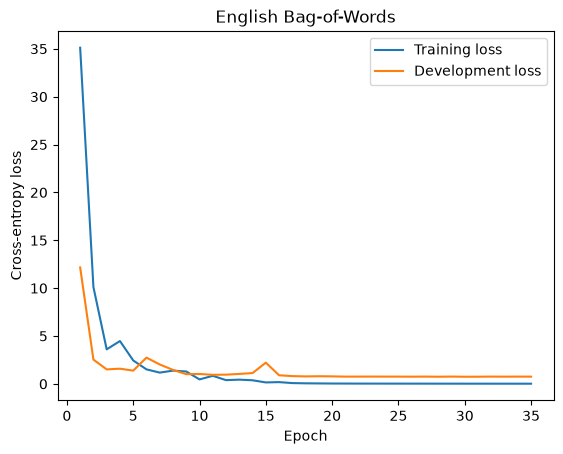

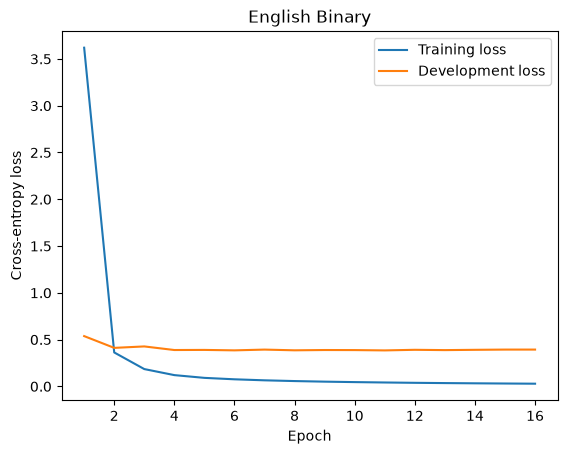

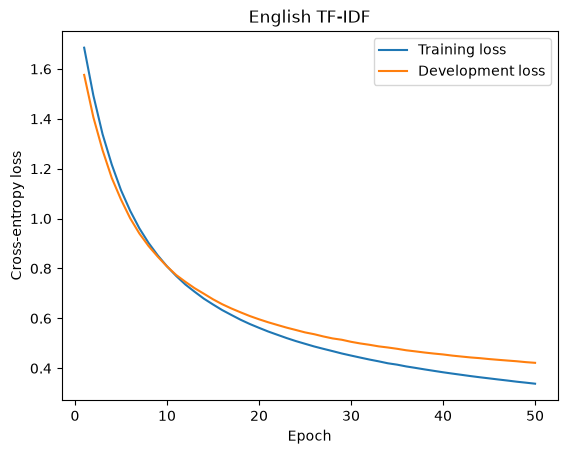

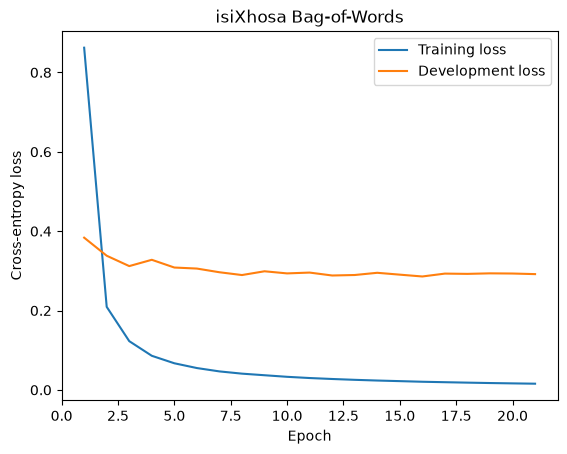

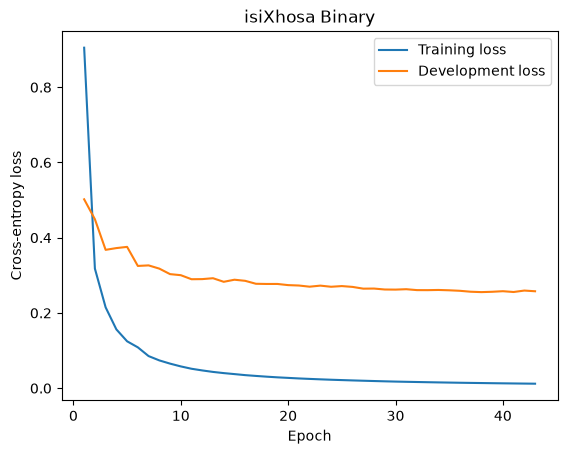

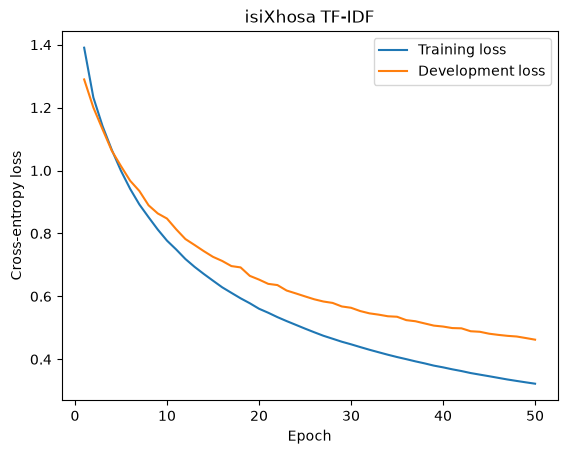

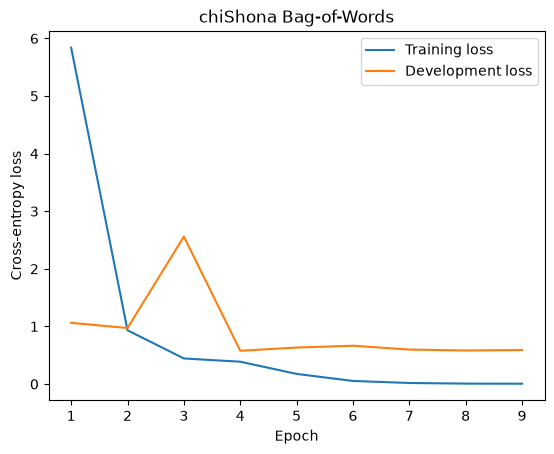

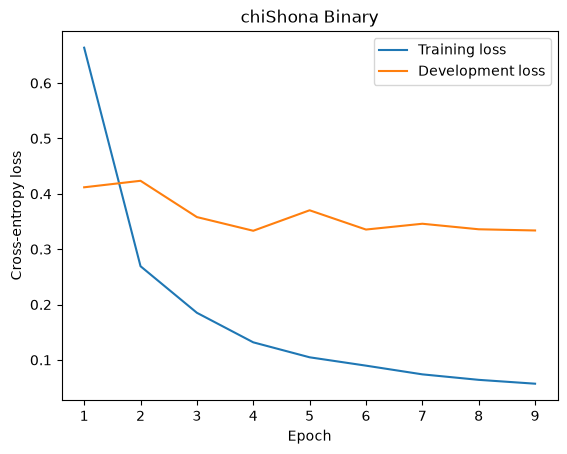

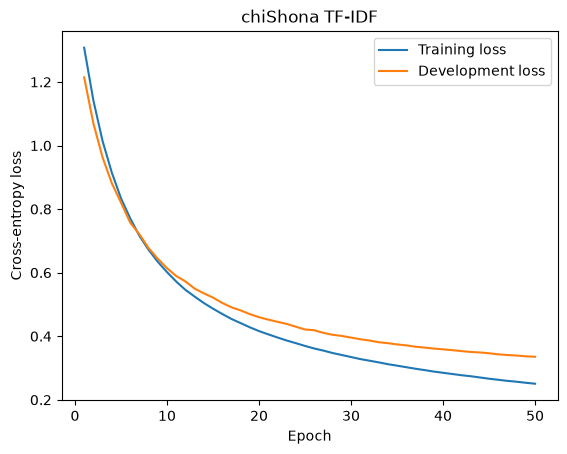

In [42]:
plot_selected_losses(eng_bow_tuning)
plot_selected_losses(eng_binary_tuning)
plot_selected_losses(eng_tfidf_tuning)

plot_selected_losses(xho_bow_tuning)
plot_selected_losses(xho_binary_tuning)
plot_selected_losses(xho_tfidf_tuning)

plot_selected_losses(sna_bow_tuning)
plot_selected_losses(sna_binary_tuning)
plot_selected_losses(sna_tfidf_tuning)

In [43]:

# Evaluate the selected model on the test set
def evaluate_selected_configuration(
    tuning_result,
    test_texts,
    test_labels
):

    # Retrieve the model selected using development accuracy
    best_model = tuning_result["best_model"]

    # Retrieve the vectoriser belonging to the selected model
    best_vectorizer = tuning_result["best_vectorizer"]

    # Retrieve the selected configuration
    best_result = tuning_result["best_result"]

    # Retrieve the selected batch size
    batch_size = best_result["batch_size"]

    # Transform the test text using the vocabulary
    # learned from the training data
    test_features = best_vectorizer.transform(
        test_texts
    )

    # Put the model in evaluation mode
    best_model.eval()

    # Store the number of correct test predictions
    correct_test_predictions = 0

    # Store the total number of test examples
    total_test_examples = 0

    # Create test mini-batches without shuffling
    test_loader = create_batches(
        test_features,
        test_labels,
        batch_size,
        shuffle=False
    )

    # Disable gradient calculations during test evaluation
    with torch.no_grad():

        # Process one test mini-batch at a time
        for features, labels in test_loader:

            # Calculate the model outputs
            outputs = best_model(features)

            # Ensure that labels are integer class indices
            labels = labels.long()

            # Select the predicted class
            _, predicted = torch.max(
                outputs.data,
                1
            )

            # Count the correct test predictions
            correct_test_predictions += (
                predicted == labels
            ).sum().item()

            # Count the test examples
            total_test_examples += labels.size(0)

    # Calculate test accuracy
    test_accuracy = (
        correct_test_predictions /
        total_test_examples
    )

    # Return the final test accuracy
    return test_accuracy

In [44]:

# DISPLAY BEST DEVELOPMENT ACCURACIES

print("English development results")

print(
    "Bag-of-Words best development accuracy: {:.2f}%"
    .format(
        eng_bow_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "Binary best development accuracy: {:.2f}%"
    .format(
        eng_binary_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "TF-IDF best development accuracy: {:.2f}%"
    .format(
        eng_tfidf_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)


print("\nisiXhosa development results")

print(
    "Bag-of-Words best development accuracy: {:.2f}%"
    .format(
        xho_bow_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "Binary best development accuracy: {:.2f}%"
    .format(
        xho_binary_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "TF-IDF best development accuracy: {:.2f}%"
    .format(
        xho_tfidf_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)


print("\nchiShona development results")

print(
    "Bag-of-Words best development accuracy: {:.2f}%"
    .format(
        sna_bow_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "Binary best development accuracy: {:.2f}%"
    .format(
        sna_binary_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

print(
    "TF-IDF best development accuracy: {:.2f}%"
    .format(
        sna_tfidf_tuning["best_result"][
            "best_development_accuracy"
        ] * 100
    )
)

English development results
Bag-of-Words best development accuracy: 88.56%
Binary best development accuracy: 88.77%
TF-IDF best development accuracy: 87.92%

isiXhosa development results
Bag-of-Words best development accuracy: 91.84%
Binary best development accuracy: 93.20%
TF-IDF best development accuracy: 88.44%

chiShona development results
Bag-of-Words best development accuracy: 90.27%
Binary best development accuracy: 88.65%
TF-IDF best development accuracy: 90.27%


In [45]:


# ENGLISH TEST ACCURACIES


eng_bow_test_accuracy = evaluate_selected_configuration(
    eng_bow_tuning,
    eng_test_texts,
    eng_test_labels
)

eng_binary_test_accuracy = evaluate_selected_configuration(
    eng_binary_tuning,
    eng_test_texts,
    eng_test_labels
)

eng_tfidf_test_accuracy = evaluate_selected_configuration(
    eng_tfidf_tuning,
    eng_test_texts,
    eng_test_labels
)



# ISIXHOSA TEST ACCURACIES


xho_bow_test_accuracy = evaluate_selected_configuration(
    xho_bow_tuning,
    xho_test_texts,
    xho_test_labels
)

xho_binary_test_accuracy = evaluate_selected_configuration(
    xho_binary_tuning,
    xho_test_texts,
    xho_test_labels
)

xho_tfidf_test_accuracy = evaluate_selected_configuration(
    xho_tfidf_tuning,
    xho_test_texts,
    xho_test_labels
)



# CHISHONA TEST ACCURACIES


sna_bow_test_accuracy = evaluate_selected_configuration(
    sna_bow_tuning,
    sna_test_texts,
    sna_test_labels
)

sna_binary_test_accuracy = evaluate_selected_configuration(
    sna_binary_tuning,
    sna_test_texts,
    sna_test_labels
)

sna_tfidf_test_accuracy = evaluate_selected_configuration(
    sna_tfidf_tuning,
    sna_test_texts,
    sna_test_labels
)

In [46]:

# DISPLAY FINAL TEST RESULTS


print("English final test results")

print(
    "Bag-of-Words test accuracy: {:.2f}%"
    .format(eng_bow_test_accuracy * 100)
)

print(
    "Binary test accuracy: {:.2f}%"
    .format(eng_binary_test_accuracy * 100)
)

print(
    "TF-IDF test accuracy: {:.2f}%"
    .format(eng_tfidf_test_accuracy * 100)
)


print("\nisiXhosa final test results")

print(
    "Bag-of-Words test accuracy: {:.2f}%"
    .format(xho_bow_test_accuracy * 100)
)

print(
    "Binary test accuracy: {:.2f}%"
    .format(xho_binary_test_accuracy * 100)
)

print(
    "TF-IDF test accuracy: {:.2f}%"
    .format(xho_tfidf_test_accuracy * 100)
)


print("\nchiShona final test results")

print(
    "Bag-of-Words test accuracy: {:.2f}%"
    .format(sna_bow_test_accuracy * 100)
)

print(
    "Binary test accuracy: {:.2f}%"
    .format(sna_binary_test_accuracy * 100)
)

print(
    "TF-IDF test accuracy: {:.2f}%"
    .format(sna_tfidf_test_accuracy * 100)
)

English final test results
Bag-of-Words test accuracy: 89.03%
Binary test accuracy: 89.77%
TF-IDF test accuracy: 90.30%

isiXhosa final test results
Bag-of-Words test accuracy: 90.57%
Binary test accuracy: 89.56%
TF-IDF test accuracy: 86.53%

chiShona final test results
Bag-of-Words test accuracy: 90.24%
Binary test accuracy: 91.06%
TF-IDF test accuracy: 92.95%


In [47]:
# Select the best feature representation for one language
def select_best_tuning_result(
    bow_tuning,
    binary_tuning,
    tfidf_tuning
):
    """
    Select the best feature representation for one language.
    Returns:The tuning result with the highest development accuracy.If accuracies are tied, the result with the lower
        development loss is returned.
    """

    # Store the three feature-method tuning results
    tuning_results = [
        bow_tuning,
        binary_tuning,
        tfidf_tuning
    ]

    # Select the model with the highest development accuracy.
    # If accuracies are tied, select the model with
    # the lower development loss.
    best_tuning = max(
        tuning_results,
        key=lambda result: (
            result["best_result"][
                "best_development_accuracy"
            ],
            -result["best_result"][
                "best_development_loss"
            ]
        )
    )

    return best_tuning
    # Store the three feature-method tuning results
    tuning_results = [
        bow_tuning,
        binary_tuning,
        tfidf_tuning
    ]

    # Select the model with the highest development accuracy.
    # If accuracies are tied, select the model with
    # the lower development loss.
    best_tuning = max(
        tuning_results,
        key=lambda result: (
            result["best_result"][
                "best_development_accuracy"
            ],
            -result["best_result"][
                "best_development_loss"
            ]
        )
    )

    return best_tuning

In [48]:
# Select the best English feature representation
best_eng_tuning = select_best_tuning_result(
    eng_bow_tuning,
    eng_binary_tuning,
    eng_tfidf_tuning
)

# Select the best isiXhosa feature representation
best_xho_tuning = select_best_tuning_result(
    xho_bow_tuning,
    xho_binary_tuning,
    xho_tfidf_tuning
)

# Select the best chiShona feature representation
best_sna_tuning = select_best_tuning_result(
    sna_bow_tuning,
    sna_binary_tuning,
    sna_tfidf_tuning
)

In [49]:
# Display the automatically selected feature method
# for each language
print(
    "Best English feature method:",
    best_eng_tuning["feature_method"]
)

print(
    "Best isiXhosa feature method:",
    best_xho_tuning["feature_method"]
)

print(
    "Best chiShona feature method:",
    best_sna_tuning["feature_method"]
)

Best English feature method: Binary
Best isiXhosa feature method: Binary
Best chiShona feature method: TF-IDF


# QUESTION 6:MODEL WEIGHT ANALYSIS

In [50]:
# Retrieve the development-selected English model
weight_model = best_eng_tuning["best_model"]

# Retrieve the vectoriser belonging to the selected model
weight_vectorizer = best_eng_tuning[
    "best_vectorizer"
]

# Retrieve the selected configuration
weight_result = best_eng_tuning["best_result"]

In [51]:
# Retrieve the vocabulary words in feature-column order
feature_names = weight_vectorizer.get_feature_names_out()

# Retrieve the learned weights from the linear layer
model_weights = (
    weight_model.linear.weight
    .detach()
    .numpy()
)

# Display the dimensions
print("Number of vocabulary words:", len(feature_names))
print("Weight matrix shape:", model_weights.shape)

Number of vocabulary words: 8675
Weight matrix shape: (6, 8675)


In [52]:
# Create a mapping from class numbers back to category names
number_to_category = {}

for category, number in eng_category_to_number.items():
    number_to_category[number] = category

print(number_to_category)

{0: 'business', 1: 'entertainment', 2: 'health', 3: 'politics', 4: 'sports', 5: 'technology'}


In [53]:
# Set the number of words to display for each category
number_of_words = 10

# Examine each news category
for class_number in range(model_weights.shape[0]):

    # Retrieve the category name
    category = number_to_category[class_number]

    # Retrieve the weights for the current category
    category_weights = model_weights[class_number]

    # Sort the feature positions from highest to lowest weight
    sorted_indices = np.argsort(category_weights)[::-1]

    # Select the words with the ten highest weights
    top_indices = sorted_indices[:number_of_words]

    # Display the category name
    print("\nCategory:", category)

    # Display each word and its corresponding weight
    for feature_index in top_indices:

        print(
            "{:<20} {:.4f}".format(
                feature_names[feature_index],
                category_weights[feature_index]
            )
        )


Category: business
business             0.7744
company              0.5356
customers            0.4728
firm                 0.4416
bank                 0.4388
energy               0.4036
workers              0.4011
rising               0.3968
companies            0.3601
firms                0.3560

Category: entertainment
music                0.7185
show                 0.7054
art                  0.5618
artist               0.5439
artists              0.5056
stars                0.4885
singer               0.4775
fans                 0.4405
studio               0.4013
prize                0.3995

Category: health
health               1.1619
nhs                  0.7790
hospital             0.6226
patients             0.6110
covid                0.5101
care                 0.4914
medical              0.4621
nurses               0.4529
treatment            0.4343
cancer               0.3942

Category: politics
government           0.8151
minister             0.7593
rishi                

# QUESTION 7:ISIXHOSA CLASS IMBALANCE

In [54]:
xho_class_counts = torch.bincount(xho_train_labels)

for category, number in xho_category_to_number.items():
    print(category, ":", xho_class_counts[number].item())

business : 50
entertainment : 350
health : 70
politics : 215
sports : 347


In [55]:
# Retrieve the development-selected isiXhosa vectoriser
xho_selected_vectorizer = best_xho_tuning[
    "best_vectorizer"
]

# Retrieve the development-selected isiXhosa configuration
xho_selected_result = best_xho_tuning[
    "best_result"
]

# Transform the isiXhosa text using the selected vectoriser
xho_train_sampling_features = (
    xho_selected_vectorizer.transform(
        xho_train_texts
    )
)

xho_dev_sampling_features = (
    xho_selected_vectorizer.transform(
        xho_dev_texts
    )
)

xho_test_sampling_features = (
    xho_selected_vectorizer.transform(
        xho_test_texts
    )
)

In [56]:
# Count the number of observations in each isiXhosa class
class_counts = torch.bincount(
    xho_train_labels
)


In [57]:
xho_learning_rate = best_xho_tuning[
    "best_result"
]["learning_rate"]

xho_batch_size = best_xho_tuning[
    "best_result"
]["batch_size"]

xho_num_epochs = best_xho_tuning[
    "best_result"
]["best_epoch"]

# Convert the selected Binary features into PyTorch tensors
xho_train_sampling_tensor = torch.tensor(
    xho_train_sampling_features.toarray(),
    dtype=torch.float32
)

xho_dev_sampling_tensor = torch.tensor(
    xho_dev_sampling_features.toarray(),
    dtype=torch.float32
)

xho_test_sampling_tensor = torch.tensor(
    xho_test_sampling_features.toarray(),
    dtype=torch.float32
)

# Create the PyTorch datasets
xho_train_sampling_dataset = TensorDataset(
    xho_train_sampling_tensor,
    xho_train_labels
)

xho_dev_sampling_dataset = TensorDataset(
    xho_dev_sampling_tensor,
    xho_dev_labels
)

xho_test_sampling_dataset = TensorDataset(
    xho_test_sampling_tensor,
    xho_test_labels
)

# Development and test data are not resampled
xho_dev_sampling_loader = DataLoader(
    xho_dev_sampling_dataset,
    batch_size=xho_batch_size,
    shuffle=False
)

xho_test_sampling_loader = DataLoader(
    xho_test_sampling_dataset,
    batch_size=xho_batch_size,
    shuffle=False
)

print("Learning rate:", xho_learning_rate)
print("Batch size:", xho_batch_size)
print("Number of epochs:", xho_num_epochs)

Learning rate: 1.0
Batch size: 128
Number of epochs: 38


In [58]:
# Train one model using a sampled training loader
# Train one model using a sampled training loader
def train_sampling_model(train_loader):
    """
    Train an isiXhosa classification model using sampled training data.

    Returns:
        The trained multinomial logistic regression model and its
        development-set accuracy.
    """

    # Reset the random seed for a fair comparison
    torch.manual_seed(42)

    # Create a new model
    model = MultinomialLogisticRegression(
        xho_train_sampling_tensor.shape[1],
        len(xho_category_to_number)
    )

    # Create the SGD optimiser
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=xho_learning_rate
    )

    # Train for the selected number of epochs
    for epoch in range(xho_num_epochs):

        model.train()

        for features, labels in train_loader:

            # Calculate the model outputs
            outputs = model(features)

            # Calculate the cross-entropy loss
            loss = F.cross_entropy(
                outputs,
                labels.long()
            )

            # Clear the previous gradients
            optimizer.zero_grad()

            # Calculate the new gradients
            loss.backward()

            # Update the model parameters
            optimizer.step()

    # Calculate development accuracy
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in xho_dev_sampling_loader:

            outputs = model(features)

            _, predicted = torch.max(
                outputs.data,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    development_accuracy = correct / total

    return model, development_accuracy

In [59]:
# Sampling rates to compare
sampling_rates = [
    0.5,
    0.75,
    1.0
]

In [60]:
# Count the number of training observations in each class
class_counts = torch.bincount(
    xho_train_labels
)

# Store the upsampling results
upsampling_results = []

# Compare the upsampling rates
for sampling_rate in sampling_rates:

    # Give minority classes larger sampling weights
    class_weights = (
        1.0 / class_counts.float()
    ) ** sampling_rate

    # Assign every article the weight of its class
    sample_weights = class_weights[
        xho_train_labels
    ]

    # Create the weighted sampler
    upsampling_sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(xho_train_labels),
        replacement=True
    )

    # Create the sampled training loader
    upsampling_loader = DataLoader(
        xho_train_sampling_dataset,
        batch_size=xho_batch_size,
        sampler=upsampling_sampler
    )

    # Train and evaluate the current model
    model, development_accuracy = train_sampling_model(
        upsampling_loader
    )

    # Store the result
    upsampling_results.append(
        {
            "sampling_rate": sampling_rate,
            "model": model,
            "development_accuracy": development_accuracy
        }
    )

    print(
        "Upsampling rate {:.2f}: {:.2f}%"
        .format(
            sampling_rate,
            development_accuracy * 100
        )
    )

# Select the best rate using development accuracy
best_upsampling_result = max(
    upsampling_results,
    key=lambda result:
    result["development_accuracy"]
)

print(
    "\nBest upsampling rate:",
    best_upsampling_result["sampling_rate"]
)

print(
    "Best upsampling development accuracy: {:.2f}%"
    .format(
        best_upsampling_result[
            "development_accuracy"
        ] * 100
    )
)

Upsampling rate 0.50: 92.52%
Upsampling rate 0.75: 92.52%
Upsampling rate 1.00: 93.20%

Best upsampling rate: 1.0
Best upsampling development accuracy: 93.20%


In [61]:
# Store the downsampling results
downsampling_results = []

# Number of classes and size of the smallest class
number_of_classes = len(class_counts)
smallest_class_size = class_counts.min().item()

# Compare the downsampling rates
for sampling_rate in sampling_rates:

    # Give majority classes smaller sampling weights
    class_weights = (
        class_counts.min().float() /
        class_counts.float()
    ) ** sampling_rate

    # Assign every article the weight of its class
    sample_weights = class_weights[
        xho_train_labels
    ]

    # Move gradually from the original dataset size
    # towards a fully balanced downsampled dataset
    balanced_size = (
        number_of_classes *
        smallest_class_size
    )

    number_of_samples = round(
        (1 - sampling_rate) * len(xho_train_labels)
        + sampling_rate * balanced_size
    )

    # Create the weighted sampler without replacement
    downsampling_sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=number_of_samples,
        replacement=False
    )

    # Create the downsampled training loader
    downsampling_loader = DataLoader(
        xho_train_sampling_dataset,
        batch_size=xho_batch_size,
        sampler=downsampling_sampler
    )

    # Train and evaluate the current model
    model, development_accuracy = train_sampling_model(
        downsampling_loader
    )

    # Store the result
    downsampling_results.append(
        {
            "sampling_rate": sampling_rate,
            "model": model,
            "development_accuracy": development_accuracy
        }
    )

    print(
        "Downsampling rate {:.2f}: {:.2f}%"
        .format(
            sampling_rate,
            development_accuracy * 100
        )
    )

# Select the best rate using development accuracy
best_downsampling_result = max(
    downsampling_results,
    key=lambda result:
    result["development_accuracy"]
)

print(
    "\nBest downsampling rate:",
    best_downsampling_result["sampling_rate"]
)

print(
    "Best downsampling development accuracy: {:.2f}%"
    .format(
        best_downsampling_result[
            "development_accuracy"
        ] * 100
    )
)

Downsampling rate 0.50: 87.76%
Downsampling rate 0.75: 91.84%
Downsampling rate 1.00: 91.84%

Best downsampling rate: 0.75
Best downsampling development accuracy: 91.84%


In [62]:
# Calculate accuracy using a DataLoader
def loader_accuracy(model, data_loader):
    """
    Calculate model accuracy using data from a DataLoader.

    Returns:The proportion of correctly classified observations.
    """

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in data_loader:

            outputs = model(features)

            _, predicted = torch.max(
                outputs.data,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    return correct / total

In [63]:
# Evaluate the best upsampling model on the test set
xho_upsampling_test_accuracy = loader_accuracy(
    best_upsampling_result["model"],
    xho_test_sampling_loader
)

# Evaluate the best downsampling model on the test set
xho_downsampling_test_accuracy = loader_accuracy(
    best_downsampling_result["model"],
    xho_test_sampling_loader
)

xho_no_sampling_test_accuracy = (
    evaluate_selected_configuration(
        best_xho_tuning,
        xho_test_texts,
        xho_test_labels
    )
)

# Display the final comparison
print("isiXhosa test accuracy comparison")

print(
    "No sampling: {:.2f}%".format(
        xho_no_sampling_test_accuracy * 100
    )
)

print(
    "Upsampling: {:.2f}%".format(
        xho_upsampling_test_accuracy * 100
    )
)

print(
    "Downsampling: {:.2f}%".format(
        xho_downsampling_test_accuracy * 100
    )
)

isiXhosa test accuracy comparison
No sampling: 89.56%
Upsampling: 90.24%
Downsampling: 89.90%


# QUESTION 8: BILINGUAL TRAINING

In [64]:
# Create one shared category mapping for a language pair
def shared_category_mapping(first_train_categories,second_train_categories):
    """
    Create a shared numerical category mapping for two languages.
    Returns:A dictionary mapping each unique category name to a numerical class label."""
    
    categories = sorted(
        set(
            first_train_categories
            + second_train_categories
        )
    )

    return {
        category: number
        for number, category in enumerate(categories)
    }


# Convert category names into shared numerical labels
def encode_shared_labels(categories, mapping):
    """ Encode category names using a shared bilingual category mapping.Returns:A PyTorch tensor containing the encoded class"""
    return torch.tensor(
        [mapping[category] for category in categories],
        dtype=torch.long
    )

In [65]:
# Vocabulary sizes to compare
bilingual_vocabulary_sizes = [
    5000,
    10000,
    20000
]


# Reuse the settings from the development-selected
bilingual_feature_method = best_xho_tuning[
    "feature_method"
]

bilingual_learning_rate = best_xho_tuning[
    "best_result"
]["learning_rate"]

bilingual_batch_size = best_xho_tuning[
    "best_result"
]["batch_size"]

bilingual_min_df = best_xho_tuning[
    "best_result"
]["min_df"]



    # Create the feature representation selected for isiXhosa
def create_bilingual_vectorizer(feature_method,vocabulary_size,min_df):
    """
    Create a bilingual vectoriser using the selected feature method.
    Returns:A configured CountVectorizer or TfidfVectorizer.
    """
    # Treat min_df=0 as no minimum-frequency filtering
    if min_df == 0:
        vectorizer_min_df = 1
    else:
        vectorizer_min_df = min_df

    # Create Bag-of-Words count features
    if feature_method == "Bag-of-Words":

        vectorizer = CountVectorizer(
            binary=False,
            max_features=vocabulary_size,
            min_df=vectorizer_min_df
        )

    # Create binary presence-or-absence features
    elif feature_method == "Binary":

        vectorizer = CountVectorizer(
            binary=True,
            max_features=vocabulary_size,
            min_df=vectorizer_min_df
        )

    # Create TF-IDF features
    elif feature_method == "TF-IDF":

        vectorizer = TfidfVectorizer(
            max_features=vocabulary_size,
            min_df=vectorizer_min_df
        )

    else:

        raise ValueError(
            "Unknown feature extraction method"
        )

    return vectorizer


# Train and compare vocabulary sizes for one bilingual pair
def tune_bilingual_pair(pair_name,first_train_texts,second_train_texts,first_dev_texts,second_dev_texts,first_train_categories,
    second_train_categories,first_dev_categories,second_dev_categories
):
    """
    Train bilingual models and compare shared vocabulary sizes.
    Returns:
        The result with the highest isiXhosa development accuracy
        and the results for all tested vocabulary sizes.
    """
    # Create one shared label mapping
    label_mapping = shared_category_mapping(
        first_train_categories,
        second_train_categories
    )

    # Combine the training text
    combined_train_texts = (
        first_train_texts
        + second_train_texts
    )

    # Combine the development text
    combined_dev_texts = (
        first_dev_texts
        + second_dev_texts
    )

    # Encode the combined training labels
    combined_train_labels = encode_shared_labels(
        first_train_categories
        + second_train_categories,
        label_mapping
    )

    # Encode the combined development labels
    combined_dev_labels = encode_shared_labels(
        first_dev_categories
        + second_dev_categories,
        label_mapping
    )

    # Encode each language's development labels separately
    first_dev_labels = encode_shared_labels(
        first_dev_categories,
        label_mapping
    )

    second_dev_labels = encode_shared_labels(
        second_dev_categories,
        label_mapping
    )

    results = []

    # Compare the required vocabulary sizes
    for vocabulary_size in bilingual_vocabulary_sizes:

        # Create one shared Binary vectoriser
        vectorizer = create_bilingual_vectorizer(
        bilingual_feature_method,
        vocabulary_size,
        bilingual_min_df
)
        

        # Fit only on the combined training text
        combined_train_features = (
            vectorizer.fit_transform(
                combined_train_texts
            )
        )

        # Transform the combined development text
        combined_dev_features = vectorizer.transform(
            combined_dev_texts
        )

        # Transform each development language separately
        first_dev_features = vectorizer.transform(
            first_dev_texts
        )

        second_dev_features = vectorizer.transform(
            second_dev_texts
        )

        # Train using the existing Question 5 function
        (
            model,
            training_losses,
            development_losses,
            development_accuracies,
            best_development_accuracy,
            best_development_loss,
            best_epoch
        ) = train_tuning_model(
            combined_train_features,
            combined_train_labels,
            combined_dev_features,
            combined_dev_labels,
            len(label_mapping),
            bilingual_learning_rate,
            bilingual_batch_size,
            maximum_epochs=50,
            patience=5
        )

        # Measure each language separately
        first_accuracy = calculate_accuracy(
            model,
            first_dev_features,
            first_dev_labels,
            bilingual_batch_size
        )

        second_accuracy = calculate_accuracy(
            model,
            second_dev_features,
            second_dev_labels,
            bilingual_batch_size
        )

        results.append(
            {
                "pair_name": pair_name,
                "vocabulary_size": vocabulary_size,
                "actual_vocabulary_size":
                    combined_train_features.shape[1],
                "first_dev_accuracy": first_accuracy,
                "second_dev_accuracy": second_accuracy,
                "model": model,
                "vectorizer": vectorizer,
                "label_mapping": label_mapping
            }
        )

        print(
            "Vocabulary size {} | "
            "isiXhosa development accuracy: {:.2f}% | "
            "Second language accuracy: {:.2f}%"
            .format(
                vocabulary_size,
                first_accuracy * 100,
                second_accuracy * 100
            )
        )

    # Select using isiXhosa development accuracy
    best_result = max(
        results,
        key=lambda result:
        result["first_dev_accuracy"]
    )

    print(
        "\nBest vocabulary size for {}: {}"
        .format(
            pair_name,
            best_result["vocabulary_size"]
        )
    )

    print(
        "Best isiXhosa development accuracy: {:.2f}%"
        .format(
            best_result["first_dev_accuracy"] * 100
        )
    )

    return best_result, results

In [66]:
best_xho_sna_result, xho_sna_results = (
    tune_bilingual_pair(
        pair_name="isiXhosa + chiShona",
        first_train_texts=xho_train_texts,
        second_train_texts=sna_train_texts,
        first_dev_texts=xho_dev_texts,
        second_dev_texts=sna_dev_texts,
        first_train_categories=xho_train_categories,
        second_train_categories=sna_train_categories,
        first_dev_categories=xho_dev_categories,
        second_dev_categories=sna_dev_categories
    )
)

Vocabulary size 5000 | isiXhosa development accuracy: 89.12% | Second language accuracy: 85.95%
Vocabulary size 10000 | isiXhosa development accuracy: 90.48% | Second language accuracy: 85.95%
Vocabulary size 20000 | isiXhosa development accuracy: 91.16% | Second language accuracy: 87.03%

Best vocabulary size for isiXhosa + chiShona: 20000
Best isiXhosa development accuracy: 91.16%


In [67]:
best_xho_eng_result, xho_eng_results = (
    tune_bilingual_pair(
        pair_name="isiXhosa + English",
        first_train_texts=xho_train_texts,
        second_train_texts=eng_train_texts,
        first_dev_texts=xho_dev_texts,
        second_dev_texts=eng_dev_texts,
        first_train_categories=xho_train_categories,
        second_train_categories=eng_train_categories,
        first_dev_categories=xho_dev_categories,
        second_dev_categories=eng_dev_categories
    )
)

Vocabulary size 5000 | isiXhosa development accuracy: 89.12% | Second language accuracy: 87.71%
Vocabulary size 10000 | isiXhosa development accuracy: 89.80% | Second language accuracy: 88.35%
Vocabulary size 20000 | isiXhosa development accuracy: 92.52% | Second language accuracy: 87.92%

Best vocabulary size for isiXhosa + English: 20000
Best isiXhosa development accuracy: 92.52%


In [68]:
# Evaluate a selected bilingual model on both test languages
def evaluate_bilingual_pair(result,first_test_texts,second_test_texts,first_test_categories,second_test_categories
):
    """
    Evaluate a selected bilingual model on both language test sets.
    Returns:The test accuracies for the first and second languages.
    """
    model = result["model"]
    vectorizer = result["vectorizer"]
    mapping = result["label_mapping"]

    # Transform both test sets
    first_test_features = vectorizer.transform(
        first_test_texts
    )

    second_test_features = vectorizer.transform(
        second_test_texts
    )

    # Encode both test-label sets with the shared mapping
    first_test_labels = encode_shared_labels(
        first_test_categories,
        mapping
    )

    second_test_labels = encode_shared_labels(
        second_test_categories,
        mapping
    )

    # Calculate separate test accuracies
    first_test_accuracy = calculate_accuracy(
        model,
        first_test_features,
        first_test_labels,
        bilingual_batch_size
    )

    second_test_accuracy = calculate_accuracy(
        model,
        second_test_features,
        second_test_labels,
        bilingual_batch_size
    )

    return first_test_accuracy, second_test_accuracy

In [69]:
# Evaluate isiXhosa and chiShona separately
(
    xho_sna_xho_test_accuracy,
    xho_sna_sna_test_accuracy
) = evaluate_bilingual_pair(
    best_xho_sna_result,
    xho_test_texts,
    sna_test_texts,
    xho_test_categories,
    sna_test_categories
)


# Evaluate isiXhosa and English separately
(
    xho_eng_xho_test_accuracy,
    xho_eng_eng_test_accuracy
) = evaluate_bilingual_pair(
    best_xho_eng_result,
    xho_test_texts,
    eng_test_texts,
    xho_test_categories,
    eng_test_categories
)


# Compare bilingual isiXhosa results with the monolingual baseline
print("Bilingual test accuracy comparison")

print(
    "Monolingual isiXhosa: {:.2f}%".format(
        xho_no_sampling_test_accuracy * 100
    )
)
print(
    "isiXhosa from isiXhosa + chiShona: {:.2f}%".format(
        xho_sna_xho_test_accuracy * 100
    )
)

print(
    "chiShona from isiXhosa + chiShona: {:.2f}%".format(
        xho_sna_sna_test_accuracy * 100
    )
)

print(
    "isiXhosa from isiXhosa + English: {:.2f}%".format(
        xho_eng_xho_test_accuracy * 100
    )
)

print(
    "English from isiXhosa + English: {:.2f}%".format(
        xho_eng_eng_test_accuracy * 100
    )
)

Bilingual test accuracy comparison
Monolingual isiXhosa: 89.56%
isiXhosa from isiXhosa + chiShona: 89.56%
chiShona from isiXhosa + chiShona: 92.41%
isiXhosa from isiXhosa + English: 90.24%
English from isiXhosa + English: 89.35%


In [70]:
# Count how many selected vocabulary terms occur in each language
def vocabulary_language_counts(
    vectorizer,
    first_train_texts,
    second_train_texts
):
    """
    Count shared vocabulary terms occurring in each language.
    Returns:The numbers of vocabulary terms occurring in each language.
    """
    vocabulary = set(
        vectorizer.get_feature_names_out()
    )

    analyzer = vectorizer.build_analyzer()

    first_language_words = set()

    for text in first_train_texts:
        first_language_words.update(
            analyzer(text)
        )

    second_language_words = set()

    for text in second_train_texts:
        second_language_words.update(
            analyzer(text)
        )

    return (
        len(vocabulary & first_language_words),
        len(vocabulary & second_language_words)
    )

In [71]:
# Vocabulary representation for isiXhosa and chiShona
xho_terms, sna_terms = vocabulary_language_counts(
    best_xho_sna_result["vectorizer"],
    xho_train_texts,
    sna_train_texts
)

print("isiXhosa + chiShona vocabulary")
print("Terms occurring in isiXhosa:", xho_terms)
print("Terms occurring in chiShona:", sna_terms)


# Vocabulary representation for isiXhosa and English
xho_terms, eng_terms = vocabulary_language_counts(
    best_xho_eng_result["vectorizer"],
    xho_train_texts,
    eng_train_texts
)

print("\nisiXhosa + English vocabulary")
print("Terms occurring in isiXhosa:", xho_terms)
print("Terms occurring in English:", eng_terms)

isiXhosa + chiShona vocabulary
Terms occurring in isiXhosa: 6545
Terms occurring in chiShona: 6876

isiXhosa + English vocabulary
Terms occurring in isiXhosa: 7723
Terms occurring in English: 13848


# QUESTION 9:MODEL EVALUATION

In [72]:
# Collect true and predicted labels from a data loader
def collect_predictions(model, data_loader):
    """
    Collect true and predicted labels from a trained model.
    Returns:Lists containing the true labels and predicted labels.
    """

    model.eval()

    true_labels = []
    predicted_labels = []

    with torch.no_grad():

        for features, labels in data_loader:

            outputs = model(features)

            _, predictions = torch.max(
                outputs.data,
                1
            )

            true_labels.extend(
                labels.tolist()
            )

            predicted_labels.extend(
                predictions.tolist()
            )

    return true_labels, predicted_labels


# Calculate all the required evaluation metrics
def calculate_metrics(true_labels,predicted_labels):
    """
    Calculate the required classification evaluation metrics.
    Returns:
        A dictionary containing accuracy and micro- and macro-averaged
        precision, recall, and F1 scores.
    """

    # Calculate accuracy without importing accuracy_score
    correct = 0

    for true_label, predicted_label in zip(
        true_labels,
        predicted_labels
    ):
        if true_label == predicted_label:
            correct += 1

    accuracy = correct / len(true_labels)

    # Calculate micro precision, recall, and F1
    (
        micro_precision,
        micro_recall,
        micro_f1,
        _
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="micro",
        zero_division=0
    )

    # Calculate macro precision, recall, and F1
    (
        macro_precision,
        macro_recall,
        macro_f1,
        _
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

In [73]:

def evaluate_selected_model(
    tuning_result,
    test_texts,
    test_labels
):
    """
    Evaluate a development-selected monolingual model.
    Returns:The evaluation metrics, true labels, and predicted labels.
    """

    # Retrieve the selected model and vectoriser
    model = tuning_result["best_model"]
    vectorizer = tuning_result["best_vectorizer"]

    # Retrieve the selected batch size
    batch_size = tuning_result[
        "best_result"
    ]["batch_size"]

    # Transform the test text using the training vocabulary
    test_features = vectorizer.transform(
        test_texts
    )

    # Create test mini-batches
    test_loader = create_batches(
        test_features,
        test_labels,
        batch_size,
        shuffle=False
    )

    # Generate predictions
    true_labels, predicted_labels = collect_predictions(
        model,
        test_loader
    )

    # Calculate the required metrics
    metrics = calculate_metrics(
        true_labels,
        predicted_labels
    )

    return metrics, true_labels, predicted_labels

In [74]:
# Evaluate the development-selected English model
(
    english_metrics,
    english_true,
    english_predicted
) = evaluate_selected_model(
    best_eng_tuning,
    eng_test_texts,
    eng_test_labels
)


# Evaluate the development-selected isiXhosa model
(
    xhosa_metrics,
    xhosa_true,
    xhosa_predicted
) = evaluate_selected_model(
    best_xho_tuning,
    xho_test_texts,
    xho_test_labels
)


# Evaluate the development-selected chiShona model
(
    shona_metrics,
    shona_true,
    shona_predicted
) = evaluate_selected_model(
    best_sna_tuning,
    sna_test_texts,
    sna_test_labels
)

In [75]:
# Display all required metrics
def display_metrics(model_name, metrics):
    """
    Display the evaluation metrics for a model.
    Returns:None."""
    print("\nModel:", model_name)

    print(
        "Accuracy: {:.4f}".format(
            metrics["accuracy"]
        )
    )

    print(
        "Micro precision: {:.4f}".format(
            metrics["micro_precision"]
        )
    )

    print(
        "Micro recall: {:.4f}".format(
            metrics["micro_recall"]
        )
    )

    print(
        "Micro F1: {:.4f}".format(
            metrics["micro_f1"]
        )
    )

    print(
        "Macro precision: {:.4f}".format(
            metrics["macro_precision"]
        )
    )

    print(
        "Macro recall: {:.4f}".format(
            metrics["macro_recall"]
        )
    )

    print(
        "Macro F1: {:.4f}".format(
            metrics["macro_f1"]
        )
    )

In [76]:
display_metrics(
    "English "
    + best_eng_tuning["feature_method"],
    english_metrics
)

display_metrics(
    "isiXhosa "
    + best_xho_tuning["feature_method"],
    xhosa_metrics
)

display_metrics(
    "chiShona "
    + best_sna_tuning["feature_method"],
    shona_metrics
)


Model: English Binary
Accuracy: 0.8977
Micro precision: 0.8977
Micro recall: 0.8977
Micro F1: 0.8977
Macro precision: 0.8953
Macro recall: 0.8946
Macro F1: 0.8944

Model: isiXhosa Binary
Accuracy: 0.8956
Micro precision: 0.8956
Micro recall: 0.8956
Micro F1: 0.8956
Macro precision: 0.8993
Macro recall: 0.7511
Macro F1: 0.7895

Model: chiShona TF-IDF
Accuracy: 0.9295
Micro precision: 0.9295
Micro recall: 0.9295
Micro F1: 0.9295
Macro precision: 0.9346
Macro recall: 0.9288
Macro F1: 0.9305


In [77]:
xho_test_sampling_loader

In [78]:
# Evaluate the best upsampling model
(
    upsampling_true,
    upsampling_predicted
) = collect_predictions(
    best_upsampling_result["model"],
    xho_test_sampling_loader
)

upsampling_metrics = calculate_metrics(
    upsampling_true,
    upsampling_predicted
)


# Evaluate the best downsampling model
(
    downsampling_true,
    downsampling_predicted
) = collect_predictions(
    best_downsampling_result["model"],
    xho_test_sampling_loader
)

downsampling_metrics = calculate_metrics(
    downsampling_true,
    downsampling_predicted
)

In [79]:
# Evaluate isiXhosa from one selected bilingual model
def evaluate_bilingual_xhosa(result):
    """
    Evaluate the isiXhosa portion of a selected bilingual model.
    Returns:
        The isiXhosa evaluation metrics, true labels, and predicted labels.
    """

    # Retrieve the model, vectoriser, and shared mapping
    model = result["model"]
    vectorizer = result["vectorizer"]
    mapping = result["label_mapping"]

    # Transform the isiXhosa test text
    test_features = vectorizer.transform(
        xho_test_texts
    )

    # Encode labels using the shared bilingual mapping
    test_labels = encode_shared_labels(
        xho_test_categories,
        mapping
    )

    # Create test mini-batches
    test_loader = create_batches(
        test_features,
        test_labels,
        bilingual_batch_size,
        shuffle=False
    )

    # Generate predictions
    true_labels, predicted_labels = collect_predictions(
        model,
        test_loader
    )

    # Calculate the required metrics
    metrics = calculate_metrics(
        true_labels,
        predicted_labels
    )

    return metrics, true_labels, predicted_labels

In [80]:
# Evaluate isiXhosa from the isiXhosa and chiShona model
(
    xho_sna_metrics,
    xho_sna_true,
    xho_sna_predicted
) = evaluate_bilingual_xhosa(
    best_xho_sna_result
)


# Evaluate isiXhosa from the isiXhosa and English model
(
    xho_eng_metrics,
    xho_eng_true,
    xho_eng_predicted
) = evaluate_bilingual_xhosa(
    best_xho_eng_result
)

In [81]:
# Store the selected isiXhosa model results
xhosa_results = [
    (
        "Monolingual "
        + best_xho_tuning["feature_method"],
        xhosa_metrics
    ),
    (
        "Upsampling",
        upsampling_metrics
    ),
    (
        "Downsampling",
        downsampling_metrics
    ),
    (
        "isiXhosa + chiShona",
        xho_sna_metrics
    ),
    (
        "isiXhosa + English",
        xho_eng_metrics
    )
]


# Display the combined isiXhosa results
print(
    "{:<23} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8}"
    .format(
        "Model",
        "Acc.",
        "Mic P",
        "Mic R",
        "Mic F1",
        "Mac P",
        "Mac R",
        "Mac F1"
    )
)

for model_name, metrics in xhosa_results:

    print(
        "{:<23} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f} "
        "{:>8.4f} {:>8.4f} {:>8.4f}"
        .format(
            model_name,
            metrics["accuracy"],
            metrics["micro_precision"],
            metrics["micro_recall"],
            metrics["micro_f1"],
            metrics["macro_precision"],
            metrics["macro_recall"],
            metrics["macro_f1"]
        )
    )

Model                       Acc.    Mic P    Mic R   Mic F1    Mac P    Mac R   Mac F1
Monolingual Binary        0.8956   0.8956   0.8956   0.8956   0.8993   0.7511   0.7895
Upsampling                0.9024   0.9024   0.9024   0.9024   0.8989   0.7938   0.8282
Downsampling              0.8990   0.8990   0.8990   0.8990   0.8903   0.7531   0.7889
isiXhosa + chiShona       0.8956   0.8956   0.8956   0.8956   0.8959   0.7431   0.7813
isiXhosa + English        0.9024   0.9024   0.9024   0.9024   0.9032   0.7563   0.7940


In [82]:
# Display a confusion matrix
def show_confusion_matrix(
    true_labels,
    predicted_labels,
    category_mapping,
    title
):
    """
    Calculate and display a confusion matrix.
    Returns:
        None.
    """
    # Arrange the category names by their numerical labels
    category_names = [
        category
        for category, number in sorted(
            category_mapping.items(),
            key=lambda item: item[1]
        )
    ]

    # Keep the numerical class order consistent
    label_numbers = list(
        range(len(category_names))
    )

    # Calculate the confusion matrix
    matrix = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=label_numbers
    )

    # Display the confusion matrix
    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=category_names
    )

    matrix_display.plot(
        xticks_rotation=45
    )

    plt.title(title)
    plt.show()

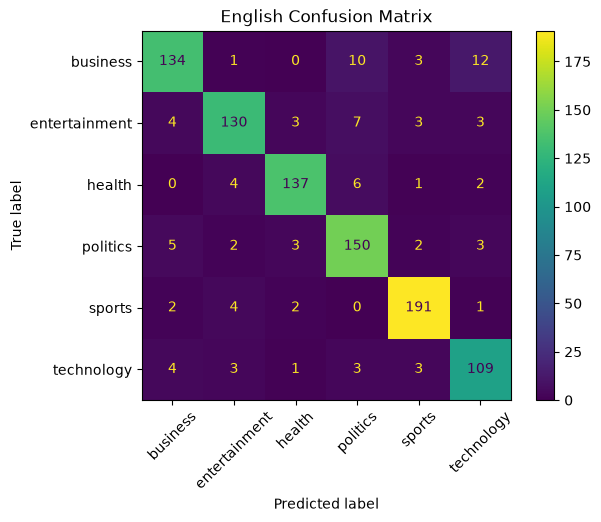

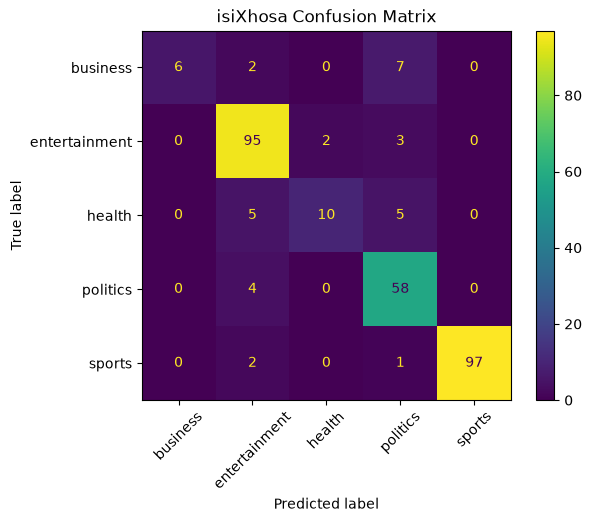

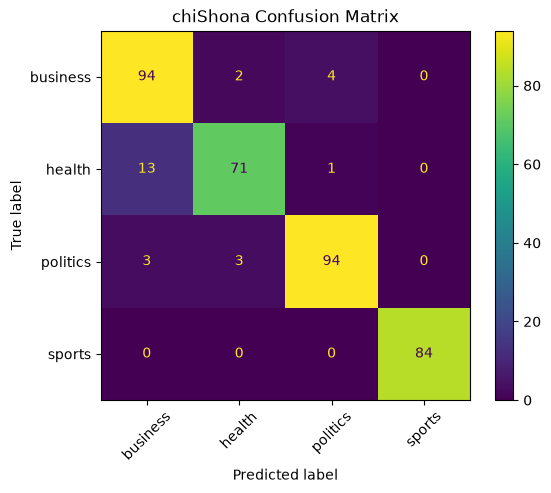

In [83]:
show_confusion_matrix(
    english_true,
    english_predicted,
    eng_category_to_number,
    "English Confusion Matrix"
)

show_confusion_matrix(
    xhosa_true,
    xhosa_predicted,
    xho_category_to_number,
    "isiXhosa Confusion Matrix"
)

show_confusion_matrix(
    shona_true,
    shona_predicted,
    sna_category_to_number,
    "chiShona Confusion Matrix"
)

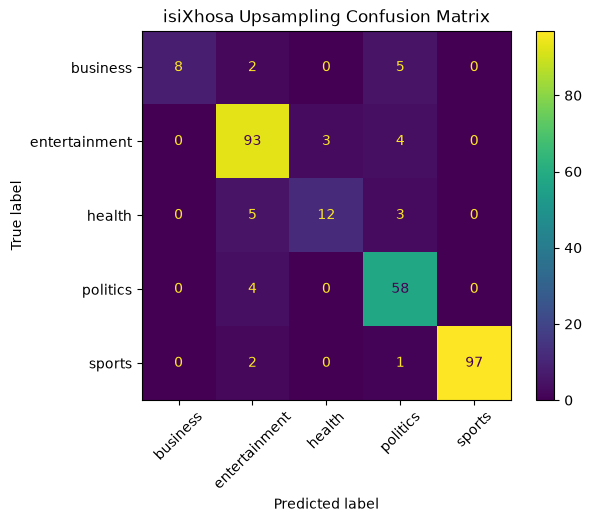

In [84]:
show_confusion_matrix(
    upsampling_true,
    upsampling_predicted,
    xho_category_to_number,
    "isiXhosa Upsampling Confusion Matrix"
)